In [1]:
# Testando se as bibliotecas estão instaladas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

print("✅ Tudo instalado e funcionando!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

✅ Tudo instalado e funcionando!
Pandas: 2.3.3
Numpy: 2.3.5


In [2]:
# ============================================================
# BLOCO 1 — Imports e configurações gerais
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Faz os gráficos aparecerem direto no notebook
%matplotlib inline

# Estilo visual mais limpo para os gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [3]:
# ============================================================
# Carregando o dataset
# ============================================================

df = pd.read_csv("ai4i2020.csv")

print(f"Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Dataset carregado com sucesso!
Linhas: 10000
Colunas: 14


In [4]:
# Visualiza as primeiras 5 linhas — como abrir a planilha no Excel
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
# Equivalente ao "Análise de Dados" do Excel:
# média, desvio padrão, mínimo, máximo de cada coluna numérica
df.describe().round(2)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


In [6]:
# ============================================================
# BLOCO 2 — Qualidade dos dados
# ============================================================

# Verifica se há dados faltantes em alguma coluna
# Em processo industrial, dados faltantes ocorrem com frequência
print("=== Valores nulos por coluna ===")
print(df.isnull().sum())

=== Valores nulos por coluna ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [7]:
# Quantas falhas vs não-falhas temos? (OK vs NOK)
contagem = df["Machine failure"].value_counts()
percentual = df["Machine failure"].value_counts(normalize=True) * 100

print("=== Distribuição de falhas ===")
print(f"Sem falha (0): {contagem[0]} peças  ({percentual[0]:.1f}%)")
print(f"Com falha (1): {contagem[1]} peças  ({percentual[1]:.1f}%)")

=== Distribuição de falhas ===
Sem falha (0): 9661 peças  (96.6%)
Com falha (1): 339 peças  (3.4%)


In [8]:
# UDI e Product ID são só identificadores — como o número de série
# Não têm valor preditivo, então removemos
# Type vira variável numérica depois — por enquanto só removemos as que não precisamos

df = df.drop(columns=["UDI", "Product ID"])

print(f"Colunas restantes: {list(df.columns)}")

Colunas restantes: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


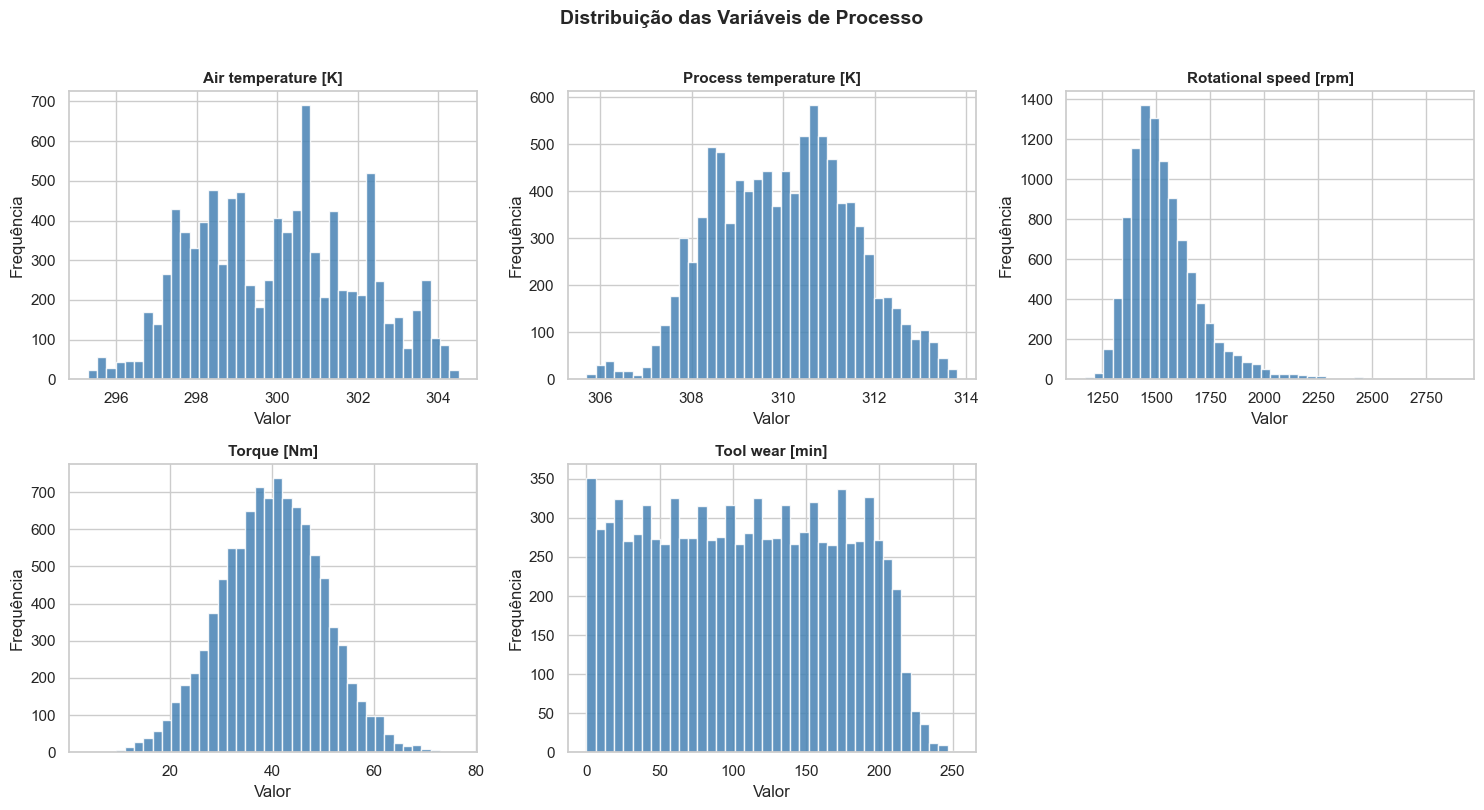

Gráfico salvo como 'distribuicao_variaveis.png'


In [9]:
# ============================================================
# BLOCO 3 — Visualizações
# ============================================================

# Histogramas de todas as variáveis numéricas
# Objetivo: ver se as distribuições fazem sentido físico
# (ex: temperatura não pode ser negativa, rotação tem limites operacionais)

colunas_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")

# Remove o subplot vazio (temos 5 variáveis em 6 espaços)
fig.delaxes(axes[5])

plt.suptitle("Distribuição das Variáveis de Processo", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("distribuicao_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo como 'distribuicao_variaveis.png'")

=== Taxa de falha por tipo de produto ===
      Total de Falhas  Total de Peças  Taxa de Falha (%)
Type                                                    
H                  21            1003               2.09
L                 235            6000               3.92
M                  83            2997               2.77


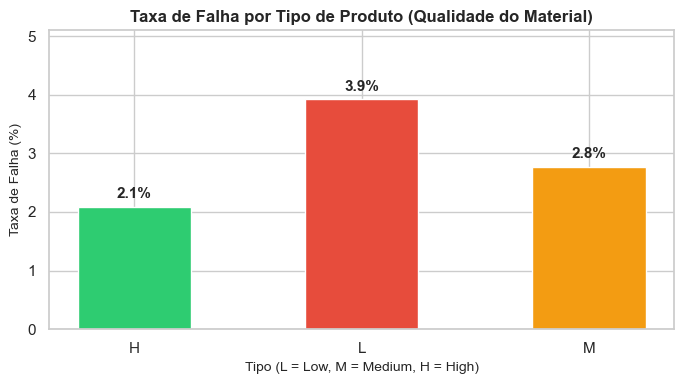

In [10]:
# Qual qualidade de material falha mais?

contagem_tipo = df.groupby("Type")["Machine failure"].agg(["sum", "count"])
contagem_tipo["taxa_falha_%"] = (contagem_tipo["sum"] / contagem_tipo["count"] * 100).round(2)
contagem_tipo.columns = ["Total de Falhas", "Total de Peças", "Taxa de Falha (%)"]

print("=== Taxa de falha por tipo de produto ===")
print(contagem_tipo)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 4))
cores = {"H": "#2ecc71", "M": "#f39c12", "L": "#e74c3c"}
bars = ax.bar(
    contagem_tipo.index,
    contagem_tipo["Taxa de Falha (%)"],
    color=[cores[t] for t in contagem_tipo.index],
    edgecolor="white",
    width=0.5
)

ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11, fontweight="bold")
ax.set_title("Taxa de Falha por Tipo de Produto (Qualidade do Material)", fontsize=12, fontweight="bold")
ax.set_xlabel("Tipo (L = Low, M = Medium, H = High)", fontsize=10)
ax.set_ylabel("Taxa de Falha (%)", fontsize=10)
ax.set_ylim(0, contagem_tipo["Taxa de Falha (%)"].max() * 1.3)
plt.tight_layout()
plt.savefig("falha_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()

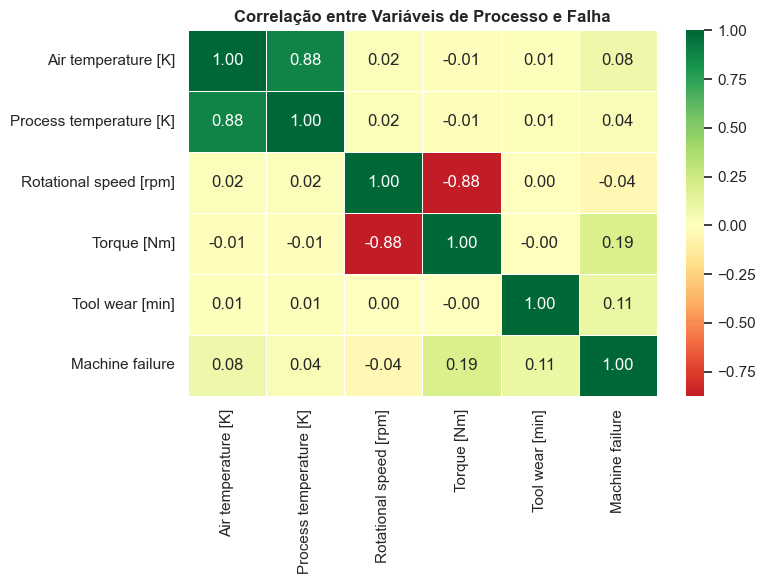

In [11]:
# Correlação entre variáveis numéricas
# Objetivo: identificar quais parâmetros de processo estão mais associados à falha

colunas_corr = colunas_numericas + ["Machine failure"]

fig, ax = plt.subplots(figsize=(8, 6))
matriz_corr = df[colunas_corr].corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlação entre Variáveis de Processo e Falha", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ============================================================
# FASE 3 — Pré-processamento
# ============================================================

# A coluna "Type" tem valores L, M, H (texto).
# O modelo não entende texto, só números.
# Usamos pd.get_dummies() — técnica chamada "One-Hot Encoding".
#
# O que ela faz na prática:
# Em vez de uma coluna "Type" com L/M/H, cria três colunas binárias:
#   Type_H = 1 se for H, 0 caso contrário
#   Type_L = 1 se for L, 0 caso contrário
#   Type_M = 1 se for M, 0 caso contrário
# Assim o modelo consegue usar essa informação sem criar hierarquia falsa
# (ex: se codificássemos L=1, M=2, H=3, o modelo acharia que H é "3x maior" que L)

df = pd.get_dummies(df, columns=["Type"], drop_first=False)

print("Colunas após encoding:")
print(list(df.columns))
print(f"\nFormato do dataset: {df.shape}")

Colunas após encoding:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M']

Formato do dataset: (10000, 14)


In [13]:
# X = tudo que o modelo vai usar para aprender (os "sensores")
# y = o que queremos prever (falhou ou não falhou)
#
# Removemos também as colunas de modo de falha (TWF, HDF, PWF, OSF, RNF)
# porque elas são consequência da falha, não causa.
# Usá-las seria "cola" — em produção real, você não teria esse dado disponível
# no momento em que precisa prever.

colunas_remover = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

X = df.drop(columns=colunas_remover)
y = df["Machine failure"]

print(f"Variáveis de entrada (X): {X.shape[1]} colunas, {X.shape[0]} linhas")
print(f"Variável-alvo (y): {y.shape[0]} valores")
print(f"\nColunas usadas no modelo:")
print(list(X.columns))

Variáveis de entrada (X): 8 colunas, 10000 linhas
Variável-alvo (y): 10000 valores

Colunas usadas no modelo:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']


In [14]:
from sklearn.model_selection import train_test_split

# Dividimos os dados em dois grupos:
#   - Treino (80%): o modelo aprende com esses dados
#   - Teste (20%):  dados que o modelo NUNCA viu — usamos para avaliar
#
# Isso é equivalente a treinar um inspetor de qualidade com 8.000 peças
# e depois testá-lo com 2.000 peças novas para ver se ele aprendeu de verdade.
#
# stratify=y garante que a proporção de falhas (3,4%) seja mantida
# igual nos dois grupos — importante por causa do desbalanceamento.
# random_state=42 garante que qualquer pessoa que rodar esse código
# vai obter exatamente a mesma divisão (reprodutibilidade).

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Dados de treino:  {X_train.shape[0]} linhas")
print(f"Dados de teste:   {X_test.shape[0]} linhas")
print(f"\nFalhas no treino: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Falhas no teste:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Dados de treino:  8000 linhas
Dados de teste:   2000 linhas

Falhas no treino: 271 (3.4%)
Falhas no teste:  68 (3.4%)


In [15]:
# ============================================================
# FASE 4 — Modelo preditivo
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Criamos o modelo com dois parâmetros importantes:
#
# n_estimators=200: quantidade de árvores na floresta.
# Mais árvores = mais estável, mas mais lento para treinar.
# 200 é um bom equilíbrio para esse tamanho de dataset.
#
# class_weight="balanced": aqui resolvemos o desbalanceamento.
# O algoritmo vai dar peso maior para as falhas (3,4%)
# e peso menor para os casos normais (96,6%), forçando o modelo
# a prestar mais atenção nos casos raros — que são exatamente
# os que importam.
#
# random_state=42: reprodutibilidade (qualquer pessoa que rodar
# esse código vai treinar o mesmo modelo).

modelo = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

# O modelo aprende a relação entre X_train e y_train
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")
print(f"Número de árvores: {modelo.n_estimators}")
print(f"Variáveis usadas:  {modelo.n_features_in_}")

Modelo treinado com sucesso!
Número de árvores: 200
Variáveis usadas:  8


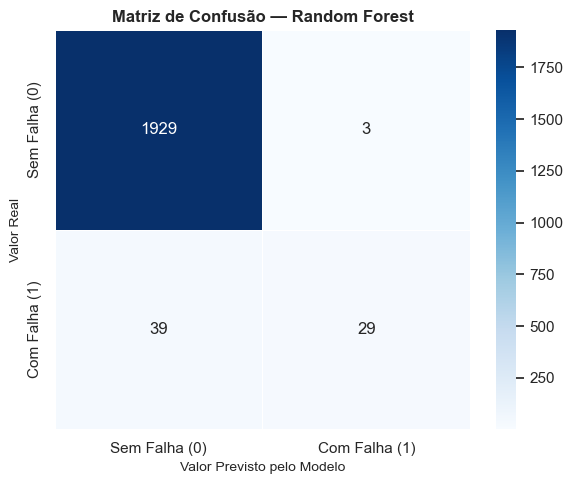


=== Relatório de Classificação ===
              precision    recall  f1-score   support

   Sem Falha       0.98      1.00      0.99      1932
   Com Falha       0.91      0.43      0.58        68

    accuracy                           0.98      2000
   macro avg       0.94      0.71      0.78      2000
weighted avg       0.98      0.98      0.98      2000



In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# O modelo agora tenta prever os dados de TESTE —
# dados que ele nunca viu durante o treinamento.
y_pred = modelo.predict(X_test)

# ---- Matriz de Confusão ----
# É a ferramenta mais honesta para avaliar um modelo de classificação.
# Ela mostra 4 situações possíveis:
#
#   Verdadeiro Negativo  (VN): modelo disse "sem falha" e estava certo
#   Falso Positivo       (FP): modelo disse "vai falhar" mas não falhou  → alarme falso
#   Falso Negativo       (FN): modelo disse "sem falha" mas falhou       → o pior caso!
#   Verdadeiro Positivo  (VP): modelo disse "vai falhar" e estava certo

cm = confusion_matrix(y_test, y_pred)
labels = ["Sem Falha (0)", "Com Falha (1)"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)
ax.set_title("Matriz de Confusão — Random Forest", fontsize=12, fontweight="bold")
ax.set_ylabel("Valor Real", fontsize=10)
ax.set_xlabel("Valor Previsto pelo Modelo", fontsize=10)
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Relatório de Classificação ----
print("\n=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred, target_names=["Sem Falha", "Com Falha"]))

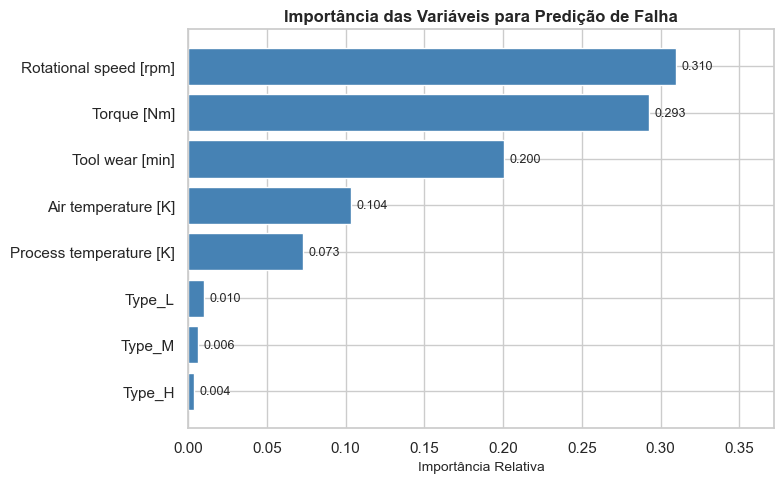

In [17]:
# Qual variável o modelo considerou mais importante para prever falha?
# Isso é o equivalente a perguntar: "qual parâmetro de processo
# você mais monitoraria se quisesse evitar paradas?"

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    importancias.index,
    importancias.values,
    color="steelblue",
    edgecolor="white"
)
ax.set_title("Importância das Variáveis para Predição de Falha", fontsize=12, fontweight="bold")
ax.set_xlabel("Importância Relativa", fontsize=10)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.set_xlim(0, importancias.values.max() * 1.2)
plt.tight_layout()
plt.savefig("importancia_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
from sklearn.metrics import classification_report

# O modelo não só diz "falha" ou "não falha" — ele calcula uma
# probabilidade para cada previsão. Por padrão, alerta se prob > 50%.
# Vamos pedir as probabilidades brutas e aplicar nosso próprio limiar.

y_prob = modelo.predict_proba(X_test)[:, 1]  # probabilidade de ser falha

# Novo threshold: alerta se probabilidade de falha > 30%
# Isso torna o modelo mais sensível — preferimos investigar casos
# duvidosos a deixar uma falha passar despercebida.
threshold = 0.30
y_pred_ajustado = (y_prob >= threshold).astype(int)

print("=== Resultado com threshold ajustado (30%) ===")
print(classification_report(
    y_test,
    y_pred_ajustado,
    target_names=["Sem Falha", "Com Falha"]
))

=== Resultado com threshold ajustado (30%) ===
              precision    recall  f1-score   support

   Sem Falha       0.99      0.99      0.99      1932
   Com Falha       0.77      0.68      0.72        68

    accuracy                           0.98      2000
   macro avg       0.88      0.83      0.85      2000
weighted avg       0.98      0.98      0.98      2000



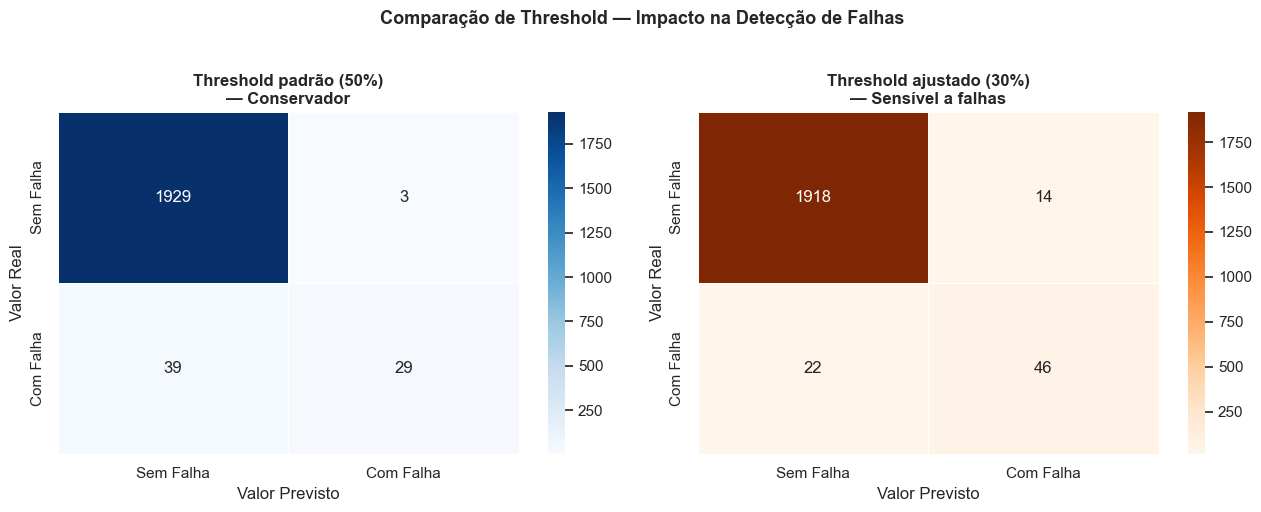

In [19]:
cm_ajustado = confusion_matrix(y_test, y_pred_ajustado)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz original (threshold 50%)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sem Falha", "Com Falha"],
            yticklabels=["Sem Falha", "Com Falha"],
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Threshold padrão (50%)\n— Conservador", fontweight="bold")
axes[0].set_ylabel("Valor Real")
axes[0].set_xlabel("Valor Previsto")

# Matriz ajustada (threshold 30%)
sns.heatmap(cm_ajustado, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Sem Falha", "Com Falha"],
            yticklabels=["Sem Falha", "Com Falha"],
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Threshold ajustado (30%)\n— Sensível a falhas", fontweight="bold")
axes[1].set_ylabel("Valor Real")
axes[1].set_xlabel("Valor Previsto")

plt.suptitle("Comparação de Threshold — Impacto na Detecção de Falhas",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparacao_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

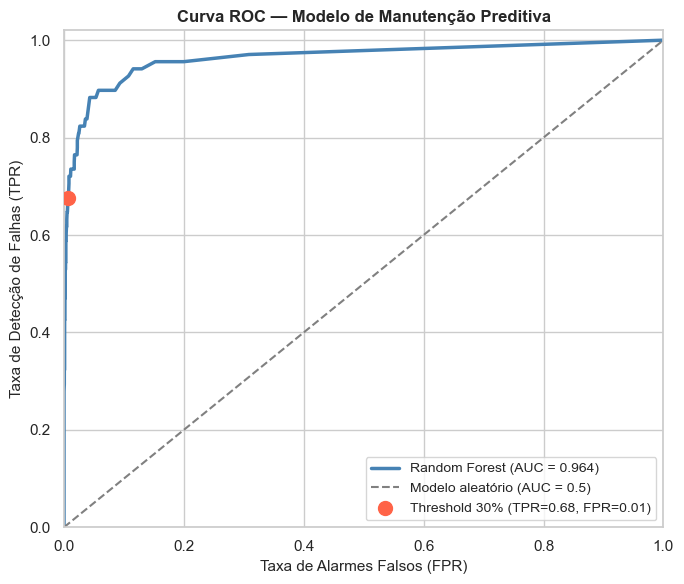

AUC do modelo: 0.964


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

# A curva ROC varre todos os thresholds possíveis (de 0 a 1)
# e para cada um calcula:
#   TPR (True Positive Rate) = recall = falhas detectadas / total de falhas reais
#   FPR (False Positive Rate) = alarmes falsos / total de casos normais
#
# O AUC (Area Under the Curve) resume tudo num número:
#   AUC = 0.5 → modelo inútil (equivale a jogar moeda)
#   AUC = 1.0 → modelo perfeito
#   AUC > 0.8 → bom para contexto industrial

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

# Curva do modelo
ax.plot(fpr, tpr, color="steelblue", lw=2.5,
        label=f"Random Forest (AUC = {auc:.3f})")

# Linha de referência: modelo aleatório (inútil)
ax.plot([0, 1], [0, 1], color="gray", lw=1.5,
        linestyle="--", label="Modelo aleatório (AUC = 0.5)")

# Marca o ponto correspondente ao threshold de 30%
idx = (abs(thresholds - 0.30)).argmin()
ax.scatter(fpr[idx], tpr[idx], color="tomato", zorder=5, s=100,
           label=f"Threshold 30% (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})")

ax.set_xlabel("Taxa de Alarmes Falsos (FPR)", fontsize=11)
ax.set_ylabel("Taxa de Detecção de Falhas (TPR)", fontsize=11)
ax.set_title("Curva ROC — Modelo de Manutenção Preditiva", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC do modelo: {auc:.3f}")

KeyError: 'Type'

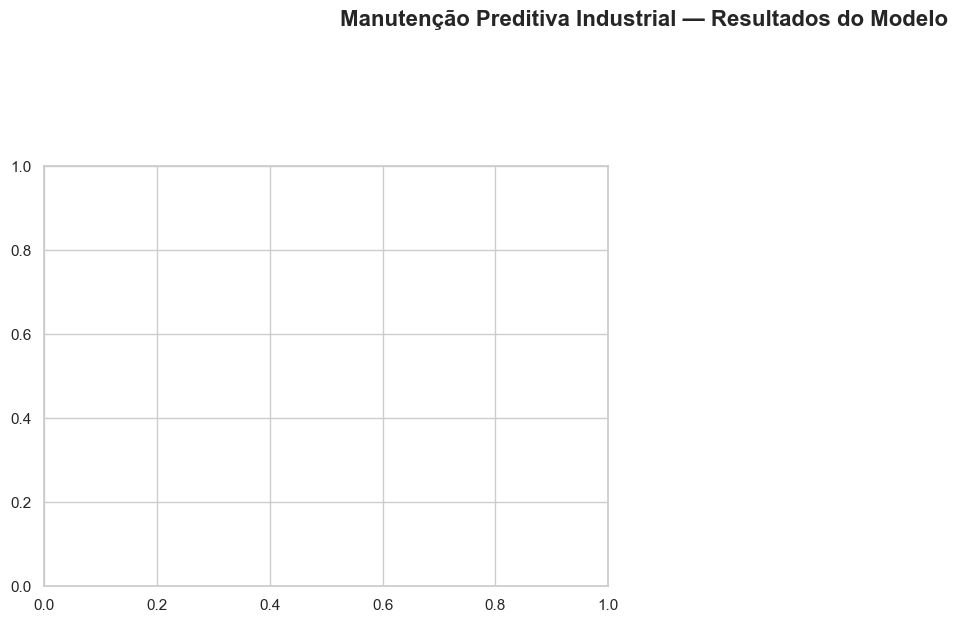

In [21]:
# Painel visual consolidado para o README e LinkedIn
# Reúne os 4 gráficos mais importantes do projeto numa única imagem

from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Manutenção Preditiva Industrial — Resultados do Modelo",
             fontsize=16, fontweight="bold", y=1.01)

# ── Gráfico 1: Taxa de falha por tipo de produto ──
ax1 = fig.add_subplot(2, 2, 1)
cores = {"H": "#2ecc71", "M": "#f39c12", "L": "#e74c3c"}
contagem_tipo = df.groupby("Type")["Machine failure"].agg(["sum", "count"])
contagem_tipo["taxa"] = contagem_tipo["sum"] / contagem_tipo["count"] * 100
bars = ax1.bar(contagem_tipo.index,
               contagem_tipo["taxa"],
               color=[cores[t] for t in contagem_tipo.index],
               edgecolor="white", width=0.5)
ax1.bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
ax1.set_title("Taxa de Falha por Qualidade do Material", fontweight="bold")
ax1.set_ylabel("Taxa de Falha (%)")
ax1.set_ylim(0, contagem_tipo["taxa"].max() * 1.35)

# ── Gráfico 2: Importância das variáveis ──
ax2 = fig.add_subplot(2, 2, 2)
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=True)
ax2.barh(importancias.index, importancias.values,
         color="steelblue", edgecolor="white")
ax2.set_title("Importância das Variáveis no Modelo", fontweight="bold")
ax2.set_xlabel("Importância Relativa")

# ── Gráfico 3: Matriz de confusão ajustada ──
ax3 = fig.add_subplot(2, 2, 3)
sns.heatmap(cm_ajustado, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Sem Falha", "Com Falha"],
            yticklabels=["Sem Falha", "Com Falha"],
            linewidths=0.5, ax=ax3)
ax3.set_title("Matriz de Confusão (Threshold 30%)", fontweight="bold")
ax3.set_ylabel("Valor Real")
ax3.set_xlabel("Valor Previsto")

# ── Gráfico 4: Curva ROC ──
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(fpr, tpr, color="steelblue", lw=2.5,
         label=f"Random Forest (AUC={auc:.3f})")
ax4.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--",
         label="Aleatório")
ax4.scatter(fpr[idx], tpr[idx], color="tomato", zorder=5, s=80,
            label=f"Threshold 30%")
ax4.set_title("Curva ROC", fontweight="bold")
ax4.set_xlabel("Taxa de Alarmes Falsos (FPR)")
ax4.set_ylabel("Taxa de Detecção (TPR)")
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("painel_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

print("Painel salvo como 'painel_resultados.png'")

AttributeError: module 'matplotlib.pyplot' has no attribute 'tigh'

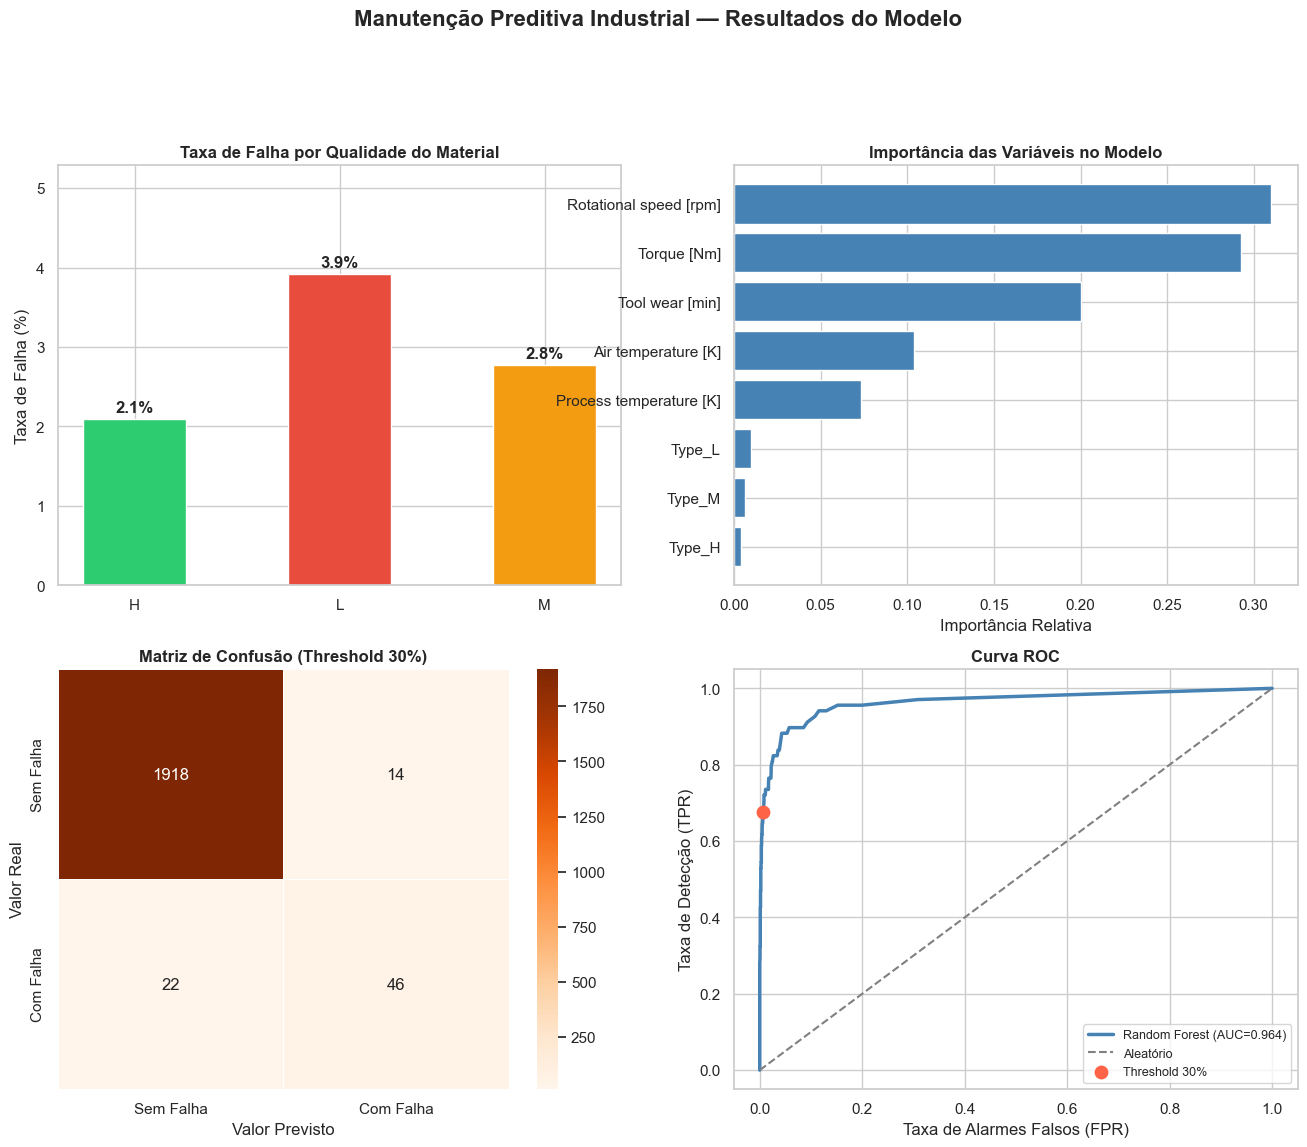

In [22]:
# Painel visual consolidado para o README e LinkedIn

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Manutenção Preditiva Industrial — Resultados do Modelo",
             fontsize=16, fontweight="bold", y=1.01)

# ── Gráfico 1: Taxa de falha por tipo de produto ──
# Reconstruímos a coluna "Type" a partir das dummies para este gráfico
# (a coluna original foi transformada na Célula 12)
ax1 = fig.add_subplot(2, 2, 1)
df_temp = df.copy()
df_temp["Type"] = (df_temp[["Type_H", "Type_L", "Type_M"]]
                   .idxmax(axis=1)
                   .str.replace("Type_", ""))

cores = {"H": "#2ecc71", "M": "#f39c12", "L": "#e74c3c"}
contagem_tipo = df_temp.groupby("Type")["Machine failure"].agg(["sum", "count"])
contagem_tipo["taxa"] = contagem_tipo["sum"] / contagem_tipo["count"] * 100
bars = ax1.bar(contagem_tipo.index,
               contagem_tipo["taxa"],
               color=[cores[t] for t in contagem_tipo.index],
               edgecolor="white", width=0.5)
ax1.bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
ax1.set_title("Taxa de Falha por Qualidade do Material", fontweight="bold")
ax1.set_ylabel("Taxa de Falha (%)")
ax1.set_ylim(0, contagem_tipo["taxa"].max() * 1.35)

# ── Gráfico 2: Importância das variáveis ──
ax2 = fig.add_subplot(2, 2, 2)
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=True)
ax2.barh(importancias.index, importancias.values,
         color="steelblue", edgecolor="white")
ax2.set_title("Importância das Variáveis no Modelo", fontweight="bold")
ax2.set_xlabel("Importância Relativa")

# ── Gráfico 3: Matriz de confusão ajustada ──
ax3 = fig.add_subplot(2, 2, 3)
sns.heatmap(cm_ajustado, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Sem Falha", "Com Falha"],
            yticklabels=["Sem Falha", "Com Falha"],
            linewidths=0.5, ax=ax3)
ax3.set_title("Matriz de Confusão (Threshold 30%)", fontweight="bold")
ax3.set_ylabel("Valor Real")
ax3.set_xlabel("Valor Previsto")

# ── Gráfico 4: Curva ROC ──
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(fpr, tpr, color="steelblue", lw=2.5,
         label=f"Random Forest (AUC={auc:.3f})")
ax4.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--",
         label="Aleatório")
ax4.scatter(fpr[idx], tpr[idx], color="tomato", zorder=5, s=80,
            label="Threshold 30%")
ax4.set_title("Curva ROC", fontweight="bold")
ax4.set_xlabel("Taxa de Alarmes Falsos (FPR)")
ax4.set_ylabel("Taxa de Detecção (TPR)")
ax4.legend(fontsize=9)

plt.tigh

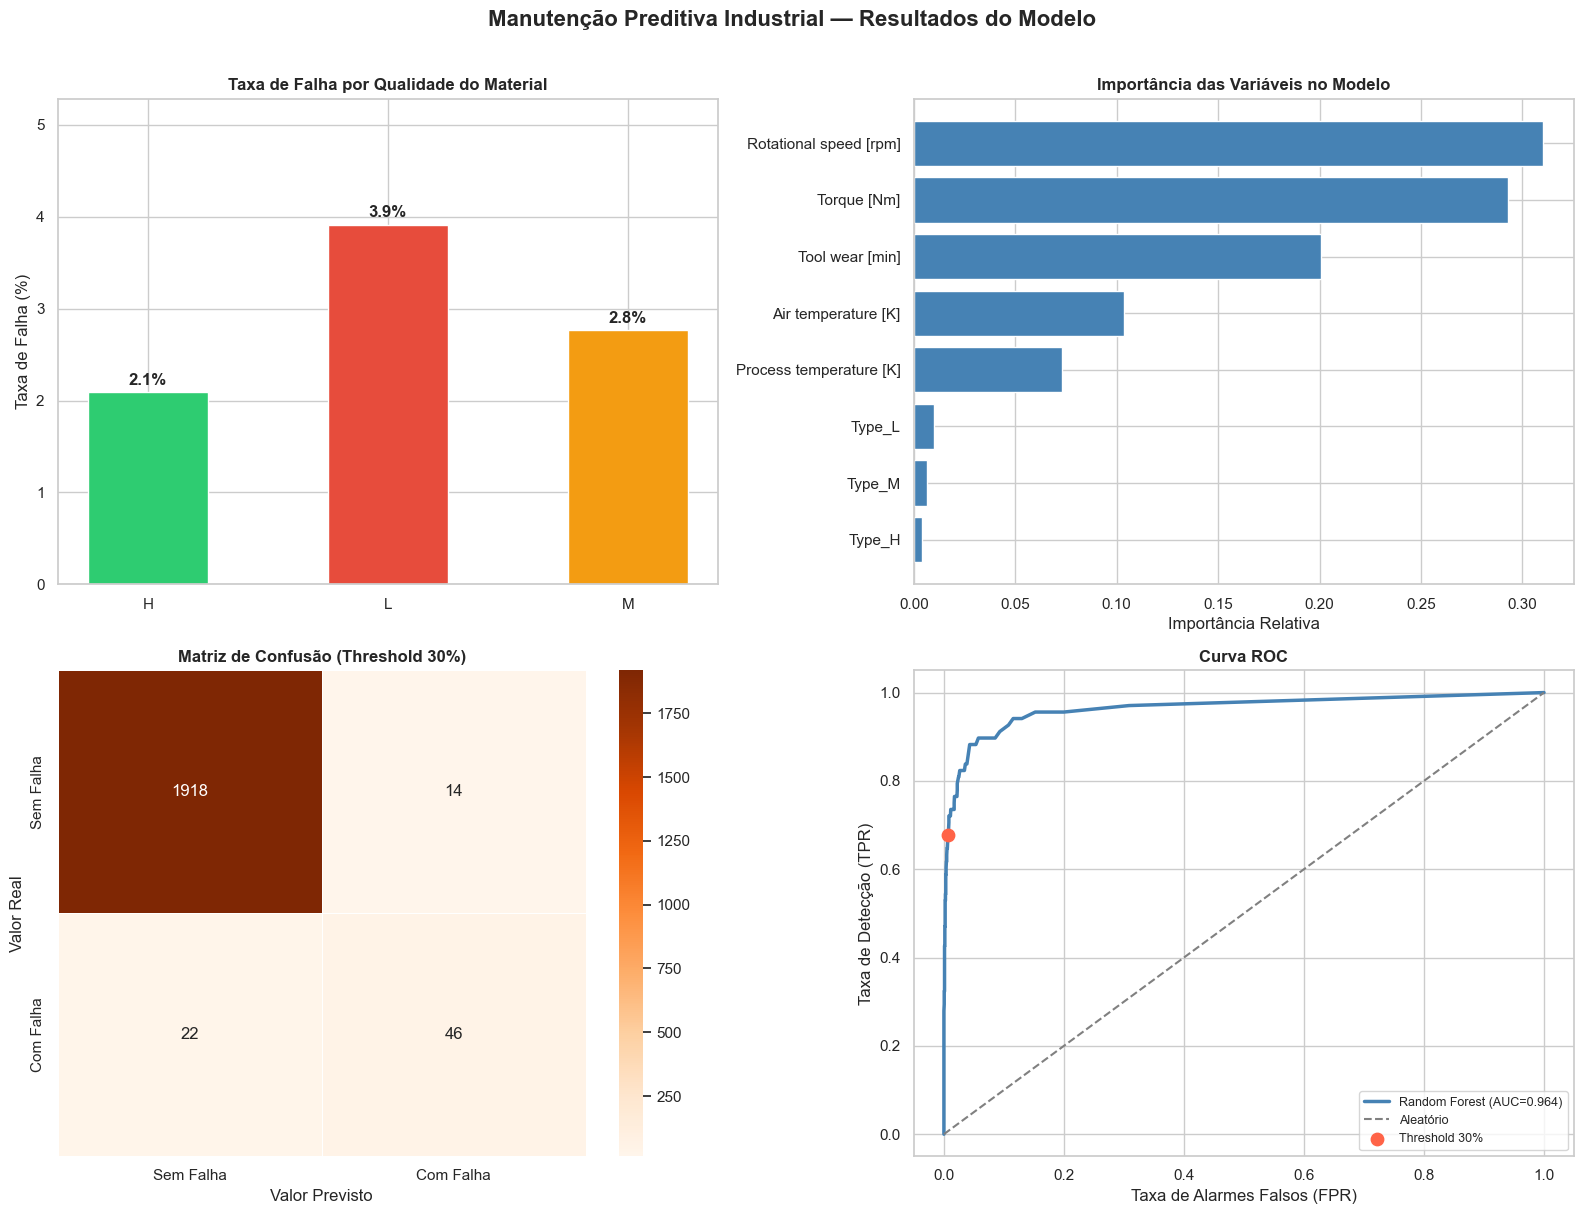

Painel salvo como 'painel_resultados.png'


In [23]:
# Painel visual consolidado para o README e LinkedIn

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Manutenção Preditiva Industrial — Resultados do Modelo",
             fontsize=16, fontweight="bold", y=1.01)

# ── Gráfico 1: Taxa de falha por tipo de produto ──
# Reconstruímos a coluna "Type" a partir das dummies para este gráfico
# (a coluna original foi transformada na Célula 12)
ax1 = fig.add_subplot(2, 2, 1)
df_temp = df.copy()
df_temp["Type"] = (df_temp[["Type_H", "Type_L", "Type_M"]]
                   .idxmax(axis=1)
                   .str.replace("Type_", ""))

cores = {"H": "#2ecc71", "M": "#f39c12", "L": "#e74c3c"}
contagem_tipo = df_temp.groupby("Type")["Machine failure"].agg(["sum", "count"])
contagem_tipo["taxa"] = contagem_tipo["sum"] / contagem_tipo["count"] * 100
bars = ax1.bar(contagem_tipo.index,
               contagem_tipo["taxa"],
               color=[cores[t] for t in contagem_tipo.index],
               edgecolor="white", width=0.5)
ax1.bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
ax1.set_title("Taxa de Falha por Qualidade do Material", fontweight="bold")
ax1.set_ylabel("Taxa de Falha (%)")
ax1.set_ylim(0, contagem_tipo["taxa"].max() * 1.35)

# ── Gráfico 2: Importância das variáveis ──
ax2 = fig.add_subplot(2, 2, 2)
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=True)
ax2.barh(importancias.index, importancias.values,
         color="steelblue", edgecolor="white")
ax2.set_title("Importância das Variáveis no Modelo", fontweight="bold")
ax2.set_xlabel("Importância Relativa")

# ── Gráfico 3: Matriz de confusão ajustada ──
ax3 = fig.add_subplot(2, 2, 3)
sns.heatmap(cm_ajustado, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Sem Falha", "Com Falha"],
            yticklabels=["Sem Falha", "Com Falha"],
            linewidths=0.5, ax=ax3)
ax3.set_title("Matriz de Confusão (Threshold 30%)", fontweight="bold")
ax3.set_ylabel("Valor Real")
ax3.set_xlabel("Valor Previsto")

# ── Gráfico 4: Curva ROC ──
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(fpr, tpr, color="steelblue", lw=2.5,
         label=f"Random Forest (AUC={auc:.3f})")
ax4.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--",
         label="Aleatório")
ax4.scatter(fpr[idx], tpr[idx], color="tomato", zorder=5, s=80,
            label="Threshold 30%")
ax4.set_title("Curva ROC", fontweight="bold")
ax4.set_xlabel("Taxa de Alarmes Falsos (FPR)")
ax4.set_ylabel("Taxa de Detecção (TPR)")
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("painel_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

print("Painel salvo como 'painel_resultados.png'")
